In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
import operator
from typing import TypedDict, Literal, Annotated
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field

In [2]:
gen_llm = ChatOllama(model = "qwen2.5:3b")
eval_llm = ChatOllama(model = "qwen2.5:3b")
optimizer_llm = ChatOllama(model = "qwen2.5:3b")

In [3]:
class PostEvaluation(BaseModel):
    evaluation: Literal["approved", "needs_improvement"] = Field(..., description = "Final evaluation result.")
    feedback: str = Field(..., description = "feedback for the tweet.")

In [4]:
structured_eval_llm = eval_llm.with_structured_output(PostEvaluation)

In [5]:
class PostState(TypedDict):
    topic: str
    content: str
    evaluation: Literal['Approved', 'NeedsImprovement']
    feedback: str
    iteration: int
    max_iterations: int
    post_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]

In [6]:
def generate(state: PostState):
    messages = [
        SystemMessage(content="You are a funny and clever Twitter/X influencer."),
        HumanMessage(content=f"""
        Write a short, original, and hilarious tweet on the topic: "{state['topic']}".

        Rules:
        - Do NOT use question-answer format.
        - Max 280 characters.
        - Use observational humor, irony, sarcasm, or cultural references.
        - Think in meme logic, punchlines, or relatable takes.
        - Use simple, day to day english
        """)
    ]
    response = gen_llm.invoke(messages).content
    return {'content': response, 'post_history': [response]}

In [7]:
def evaluate(state: PostState):
    messages = [
    SystemMessage(content="You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format."),
    HumanMessage(content=f"""
        Evaluate the following tweet:

        Tweet: "{state['content']}"

        Use the criteria below to evaluate the tweet:

        1. Originality – Is this fresh, or have you seen it a hundred times before?  
        2. Humor – Did it genuinely make you smile, laugh, or chuckle?  
        3. Punchiness – Is it short, sharp, and scroll-stopping?  
        4. Virality Potential – Would people retweet or share it?  
        5. Format – Is it a well-formed tweet (not a setup-punchline joke, not a Q&A joke, and under 280 characters)?

        Auto-reject if:
        - It's written in question-answer format (e.g., "Why did..." or "What happens when...")
        - It exceeds 280 characters
        - It reads like a traditional setup-punchline joke
        - Dont end with generic, throwaway, or deflating lines that weaken the humor (e.g., “Masterpieces of the auntie-uncle universe” or vague summaries)

        ### Respond ONLY in structured format:
        - evaluation: "approved" or "needs_improvement"  
        - feedback: One paragraph explaining the strengths and weaknesses 
        """)
        ]
    response = structured_eval_llm.invoke(messages)
    return {'evaluation':response.evaluation, 'feedback': response.feedback, 'feedback_history': [response.feedback]}

In [8]:
def optimize(state: PostState):
    messages = [
        SystemMessage(content="You punch up tweets for virality and humor based on given feedback."),
        HumanMessage(content=f"""
        Improve the tweet based on this feedback:
        "{state['feedback']}"

        Topic: "{state['topic']}"
        Original Tweet:
        {state['content']}

        Re-write it as a short, viral-worthy tweet. Avoid Q&A style and stay under 280 characters.
        """)
        ]
    response = optimizer_llm.invoke(messages).content
    iteration = state['iteration'] + 1
    return {'content': response, 'iteration': iteration, 'post_history': [response]}

In [9]:
def check_evaluation(state: PostState) -> Literal["Approved", "NeedsImprovement"]:
    if state['evaluation'] == 'approved' or state['iteration'] >= state['max_iterations']:
        return "Approved"
    else:
        return "NeedsImprovement"

In [10]:
graph = StateGraph(PostState)

graph.add_node('Generate', generate)
graph.add_node('Evaluate', evaluate)
graph.add_node('Optimize', optimize)

graph.add_edge(START, 'Generate')
graph.add_edge('Generate', 'Evaluate')
graph.add_conditional_edges('Evaluate', check_evaluation, {'Approved': END, 'NeedsImprovement': 'Optimize'})
graph.add_edge('Optimize', 'Evaluate')

workflow = graph.compile()

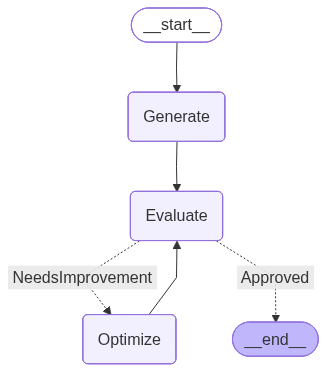

In [11]:
workflow

In [12]:
initial_state = {
    "topic": "SWOT",
    "iteration": 1,
    "max_iterations": 5
}
final_state = workflow.invoke(initial_state)

In [14]:
final_state

{'topic': 'SWOT',
 'content': "🚨 Dive into my SWOT analysis: S: Super stoked to binge-watch the new series 🎬. W: Will nosh on pizza 🍕. O: Open to any last-minute plans with buddies. T: Ruined by boredom if I'm solo! #SWOTsAlwaysFun",
 'evaluation': 'approved',
 'feedback': 'The tweet is well-formed, adhering to Twitter character limits. It uses a creative SWOT analysis format that is unique in its context of a binge-watch scenario. The humor comes from the juxtaposition of enjoying new content versus eating pizza, which is relatable and slightly irreverent. However, it lacks originality by not being overly innovative compared to other viral or meme-worthy tweets but still manages to be fresh within its category. Overall, it has potential for engagement due to its punchiness and humor.',
 'iteration': 3,
 'max_iterations': 5,
 'post_history': ['WATCH OUT! Just found out my SWOT analysis for the weekend was: S = Super excited to binge watch new series. W = Will definitely order pizza 🍕. 

In [15]:
for posts in final_state['post_history']:
    print(posts)

WATCH OUT! Just found out my SWOT analysis for the weekend was: S = Super excited to binge watch new series. W = Will definitely order pizza 🍕. O = Open for any last minute plans with friends. T = Totally ruined by boredom if I’m alone. #SWOTsAlwaysFun
🚨 Watch out! My SWOT analysis? S: Super excited to binge-watch new series. W: Will definitely order pizza 🍕. O: Open for any last-minute plans with friends. T: Totally ruined by boredom if I'm alone. #SWOTsAlwaysFun
🚨 Dive into my SWOT analysis: S: Super stoked to binge-watch the new series 🎬. W: Will nosh on pizza 🍕. O: Open to any last-minute plans with buddies. T: Ruined by boredom if I'm solo! #SWOTsAlwaysFun
